<span style="font-family: Comic Sans MS; font-size:1.2em;color:black;"> 
    </p> 

# Matrix Product Density Operators: Lindblad Equations:

\begin{equation}
	\dot{\rho} = \mathcal{L} [ \rho] = -i\left[H,\rho \right] + \sum_{\mu}\left( L_\mu \rho L_\mu^\dagger - \frac{1}{2} \{ L_\mu^\dagger L_\mu,  \rho \} \right) , 
	\label{master0}
\end{equation}

#### Where $\rho$ is the density matrix of the system, $\mathcal{L}$ is the Liouvillian superoperator, $H$ the Hamiltonian of the system, and $\{ L_\mu, L_\mu^\dagger \}$ the Lindblad operators responsible for the dissipation.

#### One can also represent the master equation in terms of superoperators and superkets as following:
# \begin{equation}\dot{|{\rho}\rangle}_\sharp = \mathcal{L}_\sharp {|\rho\rangle}_\sharp\end{equation}

#### based on choi's representation
\begin{equation}
\begin{split}
	\mathcal{L}_\sharp& \equiv -i \left(H\otimes \mathbb{I} - \mathbb{I}\otimes H^{\rm T} \right)\\
	&+ \sum_\mu \left(L_\mu\otimes L^*_\mu -\frac{1}{2}L_\mu^\dagger L_\mu \otimes\mathbb{I} - \frac{1}{2}\mathbb{I}\otimes L^*_\mu L_\mu^{\rm T} \right). 
\end{split}
\end{equation}

#### <font color='green'> Now in terms of matrix product states and matrix product density operators, we have</font>


#### $|\psi_{\mathrm{mps}}\rangle = \sum_{s_1,\ldots,s_N=1}^d {\rm Tr}(A^{s_1}_1 \ldots A^{s_N}_N) |s_1,\ldots,s_N\rangle$

#### $  \rho = \sum_{s_1,s_1',\ldots,s_N,s_N'=1}^d {\rm Tr} (M^{s_1,s_1'}_1 \ldots M^{s_N,s_N'}_N) \nonumber \times |s_1,\ldots,s_N\rangle\langle s_1',\ldots,s_N'|$

#### $M^{s_k,s_k'}_k$ are $D_k^2\times D_{k+1}^2$

####  $M_k^{s,s'}=\sum_{a=1}^{d_k} A_k^{s,a} \otimes (A_k^{s',a})^\ast$

#### the evolution of spin systems in the presence of decoherence:

#### $  \frac{d}{dt}\rho = i \left[\mathcal{H},\rho\right]+ \gamma \sum_i (\sigma^x_i\rho\sigma^x_i - \rho) =: {\cal L}\rho$



#### Let us denote by ${\cal E}({\cal L},t) =\exp(t {\cal L})$ the CPM so that $\rho(t) ={\cal E}({\cal L},t)\rho(0)$. We will decompose this operator as follows

#### $ {\cal E}({\cal L},\Delta t) \simeq \left[{\cal E}({\cal L}_{e},\Delta t/2) {\cal E}({\cal L}_{o},\Delta t){\cal E}({\cal L}_{e},\Delta t/2)\right]^n$

#### Splitting the Liouvillian time evolution to two parts: ${\cal L} = {\cal L}_{o}+ {\cal L}_{e}$ which acts or odd and even sites (TEBD)

####  <font color='red'> What are ${\cal E}({\cal L}_e,\Delta t/2)$ or ${\cal E}({\cal L}_o,\Delta t)$ exactly? One needs to devide them to even and odd sites as it is explained above. </font>
    
### done! 

<span style="font-family: Comic Sans MS; font-size:1.2em;color:black;"> 
    </p> 

## Hamiltonian:

$\displaystyle H = - \frac{1}{2}\sum_n^N h_n \sigma_z(n) - \frac{1}{2} \sum_n^{N-1} [ J_x^{(n)} \sigma_x(n) \sigma_x(n+1) + J_y^{(n)} \sigma_y(n) \sigma_y(n+1) +J_z^{(n)} \sigma_z(n) \sigma_z(n+1)]$

In [1]:
from mpi4py import MPI
from mpi4py.MPI import ANY_SOURCE
comm = MPI.COMM_WORLD
nprocs = comm.Get_size()
rank = comm.Get_rank()
print(nprocs, rank)

1 0


In [2]:
version= MPI.Get_version()
print( "mpi version is ",version)

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()
print ("size is ",size)

universe_size=comm.Get_attr(MPI.UNIVERSE_SIZE)
print ("universe size is ",universe_size)

mpi version is  (3, 1)
size is  1
universe size is  1


In [3]:
import multiprocessing
multiprocessing.cpu_count()


12

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import qutip as qp
from scipy.linalg import expm

In [6]:
from tensor_networks_simulations.mps.states import MPDO, MPS
from tensor_networks_simulations.mps.algorithms import tebd_alg_choi, one_time_step_2nd_order, one_time_step_2nd_order_2approach
from tensor_networks_simulations.mps.models import BondHamiltonian, H_bond_choi, HBond
from tensor_networks_simulations.mps.tools import correlation_one_site_mix, projection_Normalization_Mix, T_spin_correl_mix, apply_one_site_op_mix_state, right_normalization_mpdo, apply_one_site_op_mpo
from tensor_networks_simulations.general_tools import ED_tools as sf
from tensor_networks_simulations.general_tools.plot_tools import figure_styling
figure_styling()

In [7]:
L = 4

In [8]:
mpdo_gen = MPDO()
rho = mpdo_gen.mix_state_mpdo(L)

In [9]:
psi = MPS.GHZ_state(L)
rho = MPDO.from_mps(psi)
np.reshape(np.sqrt(np.tensordot(rho.Ms[3], np.conj(rho.Ms[3]), axes=([0,1],[0,1]))), (1,1)).shape

(1, 1)

In [10]:
def linblad(op, gamma):
    op1 = np.kron(op, np.conj(op))
    op2 = np.kron(np.conj(op.T).dot(op), np.eye(2))
    op3 = np.kron(np.eye(2), op.T.dot(np.conj(op)))
    noise = gamma*(op1 - 0.5*op2- 0.5*op3)
    return noise

In [11]:
# array of spin energy splittings and coupling strengths.
hzs = -0.0 * np.ones(L) 
Jzs = -1. * np.ones(L)
Jxs = -0. * np.ones(L)
Jys = -0. * np.ones(L)


hxs = -0.8 * np.ones(L)
mus = -0.0 * np.ones(L)
gamma= 0.01

chi_max = 128
dt=0.01
dt_list = np.array([dt,]*L)

scale = 1

Hb = HBond(L, Jxs, Jys, Jzs, hxs, hzs, mus)

Hs_list = [scale*Hb.h_bond(i)+Hb.new_lindbladian(Hb.sx, 1, gamma) for i in range(L-1)]
#Gs_list = [np.reshape(expm(dt*linblad(Hb.sx, gamma)), (2,2,2,2)) for i in range(L)] 



tot_steps = int(8/(scale*dt))

#Hb.h_bond_choi_decoherence(2, gamma)
Hb.h_bond(2).all() == Hb.h_bond(2).T.all() 

True

In [12]:
#print(np.tensordot(Hb.sz, rho.Ms[i], axes=([0,1],[0,1])).shape)

def apply_op_site_i(rho, op, i, d=2):
    Mlist=[];
    O = np.tensordot(Hb.sz, rho.Ms[i], axes=([0,1],[0,1])) # (L_i, R_i)
    for j in range(len(rho.Ms)):
        if j != i:
            I  = np.tensordot(np.eye(d), rho.Ms[i], axes=([0,1],[0,1])) # (L_i, R_i)
            Mlist.append(rho.Ms[j])
        else:
             Mlist.append(np.tensordot(op, rho.Ms[i], axes=([0,1],[0,1])))
    rho_new = MPDO(Mlist, rho.Ss, rho.bonds)
    return rho_new



def expectation_value_op(rho, op, j, d=2):
    i = 0
    T = np.tensordot(op, rho.Ms[j],([0,1],[0,1]))      #(a_j, a_j+1)
    if i == j:
        C = T
        i = i+1
    else:
        C = np.tensordot(np.eye(d), rho.Ms[i],([0,1],[0,1])) # (a_i+1, a_i+1)
        i = i+1
    while i < L:
        if i == j :
            BB = T
            C = np.tensordot(C, BB, ([1],[0]))     #(a_i, a_i+2)
            i = i+1
        elif i != j :
            BB = np.tensordot(np.eye(d), rho.Ms[i],([0,1],[0,1])) # (a_i+1, a_i+1)
            C = np.tensordot(C, BB, ([1],[0]))     #(a_i, a_i+2)
            i=i+1;
    return np.squeeze(C)



In [13]:
ms = expectation_value_op(rho, Hb.sz, 2)
ms1 = apply_op_site_i(rho, Hb.sz, 2)
ms.shape, ms1

((), <tensor_networks_simulations.mps.states.MPDO at 0x7fb4becff2b0>)

In [14]:
rho_new = apply_one_site_op_mix_state(rho, Hb.sz, 1)
print(projection_Normalization_Mix(rho.Ms, rho_new.Ms, L))

def op_tot(rho, op):
    op_val_list = []
    for i in range(len(rho.Ms)):
        rho_new = apply_one_site_op_mix_state(rho, op, i)
        op_i = projection_Normalization_Mix(rho.Ms, rho_new.Ms, L)
        op_val_list.append(op_i)
    return np.sum(op_val_list)/len(rho.Ms)

0.0


In [15]:
def expectation_value(rho, op):
    ms = []
    for i in range(len(rho.Ms)):
        xrho = apply_one_site_op_mpo(rho, op, i)
        m = expectation_value_op(xrho, Hb.s0, 0)
        ms.append(m)
    return sum(ms)/(expectation_value_op(rho, Hb.s0, 0)*len(rho.Ms))

In [16]:
print([expectation_value_op(rho, Hb.s0, 2)])

[array(1.)]


In [17]:
#Bs = right_normalization_mpdo(rho)
#print([np.tensordot(Bs[i], np.conj(Bs[i]), axes=([0,1,2],[0,1,2])) for i in  range(L) ])

In [18]:
mag_t = []
mx_ts =[]
mx_ts_norms = []
ts = []
t=0
deltat=0
disc_err = []
discerr = 0.
for i in range(tot_steps):
    rho, disc =  one_time_step_2nd_order(rho, Hs_list, chi_max, L, dt_list, epsilon=10**(-10))
    szrho = apply_one_site_op_mpo(rho, Hb.sx, i)
    #rho = MPDO.update_mpo_with_schmidt_vals(rho)
    #rho, disc = one_time_step_2nd_order_2approach(rho, Hs_list, Gs_list, chi_max, L, dt_list, epsilon=10**(-8))
    #print(rho.bonds)
    #Bs = right_normalization_mpdo(rho)
    #print([sum(np.diag(np.tensordot(Bs[i], np.conj(Bs[i]), axes=([0,1,2],[0,1,2])))) for i in  range(L) ])
    #print(rho.bonds, f"{expectation_value_op(rho, Hb.s0, 2).real:.4f}")
    #Bs, Ss = mpdo_gen.schmidt_vals_from_mpdo(Bs, rho.bonds)
    #rho = MPDO(Bs, Ss, rho.bonds)
    t += dt
    discerr += disc
    if np.mod(i,10)==0:
        Mz = np.sum([expectation_value_op(rho, Hb.sz, i) for i in range(L)])/L
        Mx = np.sum([expectation_value_op(rho, Hb.sx, i) for i in range(L)])/L
        print(f"norm = {np.sum([expectation_value_op(rho, Hb.s0, i) for i in range(L)])/L:.5f}, Mx={Mx.real:.3f} and {Mx.real/np.sqrt(expectation_value_op(rho, Hb.s0, 2)):.3f}, Mz={Mz.real:.3f}, t={t}, disc_error = {discerr}")
        #print([correlation_one_site_mix(rho.Ms, rho.Ss, rho.Ss, rho.Ms, Hb.sx, i) for i in range(L)])
        #Mz = op_tot(rho, Hb.sz)
        Mx = expectation_value(rho, Hb.sx)
        mag_t.append(Mz)
        mx_ts.append(Mx)
        
        mx_ts_norms.append(Mx.real/(expectation_value_op(rho, Hb.s0, 0)))
        disc_err.append(discerr)
        ts.append(t)
        #print(t)
    #print(np.sum([correlation_one_site_mix(rho.Ms, rho.Ss, rho.Ss, rho.Ms, Hb.sz, i) for i in range(L)])/L)
    #print(np.sum([T_spin_correl_mix(rho.Ms, Hb.sz,rho.Ms, L, i) for i in range(L)]).real/L)
    #print("----------")
    #print(projection_Normalization_Mix(rho.Ms, rho.Ms, L))
    #print(Mz)
    
    
    
rho.bonds, Mz

norm = 1.00000+0.00000j, Mx=1.000 and 1.000-0.000j, Mz=0.000, t=0.01, disc_error = 1.088547039888335e-11
norm = 0.99991+0.00000j, Mx=0.964 and 0.964-0.000j, Mz=0.000, t=0.10999999999999999, disc_error = 1.346285888103022e-10
norm = 0.99944-0.00000j, Mx=0.877 and 0.878+0.000j, Mz=-0.000, t=0.21000000000000005, disc_error = 6.054352176317399e-10
norm = 0.99837+0.00000j, Mx=0.757 and 0.757-0.000j, Mz=0.000, t=0.3100000000000001, disc_error = 6.054352176317399e-10
norm = 0.99672+0.00000j, Mx=0.627 and 0.628-0.000j, Mz=-0.000, t=0.4100000000000002, disc_error = 6.054352176317399e-10
norm = 0.99461+0.00000j, Mx=0.511 and 0.512-0.000j, Mz=-0.000, t=0.5100000000000002, disc_error = 6.054352176317399e-10
norm = 0.99221+0.00000j, Mx=0.426 and 0.428-0.000j, Mz=-0.000, t=0.6100000000000003, disc_error = 6.054352176317399e-10
norm = 0.98966-0.00000j, Mx=0.379 and 0.381+0.000j, Mz=-0.000, t=0.7100000000000004, disc_error = 6.054352176317399e-10
norm = 0.98708-0.00000j, Mx=0.367 and 0.369+0.000j, Mz=

([1, 4, 16, 4, 1], (2.1623815016256814e-15+7.111677442459425e-15j))

/home/younes/anaconda3/envs/TN_self_env/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/younes/anaconda3/envs/TN_self_env/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


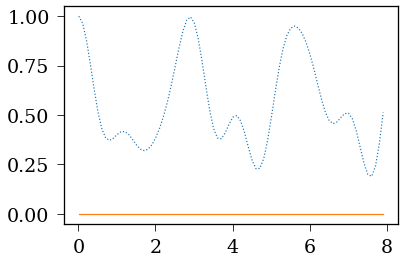

In [19]:
plt.plot(ts, np.array(mx_ts), ':', label='$<S_x> TEBD$')
plt.plot(ts, np.array(mag_t), '-', label='$<S_x> TEBD$')

In [20]:



def integrate(L, hx, hz, Jx, Jy, Jz, psi0, tlist, gammas, solver):
    sx_list, sy_list, sz_list, sp_list, sm_list = sf.spin_operator(L)
    # si = qeye(2)
    # sx = sigmax()
    # sy = sigmay()
    # sz = sigmaz()

    expect_list = []
    for i in range(L):
        expect_list.append(sz_list[i])
    for i in range(L):
        expect_list.append(sx_list[i])
    


    # construct the hamiltonian
    H = 0

    # energy splitting terms
    for n in range(L):
        H += hz[n] * sz_list[n]
        H += hx[n] * sx_list[n]

    # interaction terms
    for n in range(L-1):
        H += Jx[n] * sx_list[n] * sx_list[n+1]
        H += Jy[n] * sy_list[n] * sy_list[n+1]
        H += Jz[n] * sz_list[n] * sz_list[n+1]

    # collapse operators
    c_op_list = []

    # spin dephasing
    for n in range(L):
        if gammas[n] > 0.0:
            c_op_list.append(np.sqrt(gammas[n]) * sx_list[n])

    
    # evolve and calculate expectation values
    if solver == "me":
        result = qp.mesolve(H, psi0, tlist, c_op_list, expect_list)
    elif solver == "mc":
        ntraj = 500 
        result = qp.mcsolve(H, psi0, tlist, c_op_list, expect_list, ntraj)
    # if solver == "me":
    #     return result
    # else: 
    return result.expect






In [21]:


solver = "me"   # use the ode solver
#solver = "mc"   # use the monte-carlo solver


# decoherence rate
gammas = gamma * np.ones(L)
print(gammas)

init_ghz = [(qp.basis(2, 0)+qp.basis(2, 1))/np.sqrt(2.)]*L
init = [qp.basis(2, 0)/np.sqrt(1.), qp.basis(2, 1)/np.sqrt(1.)]*int(L/2)
#print(init)




# intial state, first spin in state |1>, the rest in state |0>
psi_list = []
psi_list.append(qp.basis(2,1))
for n in range(L-1):
    psi_list.append(qp.basis(2,0))
    
    
psi0 = qp.tensor(init_ghz) 
#psi0 = qp.ghz_state(L)

tlist = np.linspace(0, 15, 100)

expts = integrate(L, hxs, hzs, Jxs, Jys, Jzs, psi0, tlist, gammas, solver)

[0.01 0.01 0.01 0.01]


In [22]:
mz_ex = []
mx_ex = []
for i, t in enumerate(tlist):
    mz_ex.append(np.sum([expts[j][i] for j in range(L)])/L)
    mx_ex.append(np.sum([expts[j][i] for j in range(L, 2*L)])/L)

In [23]:
len(expts)

8

In [24]:
sx_list, sy_list, sz_list, _, _ = sf.spin_operator(4)


/home/younes/anaconda3/envs/TN_self_env/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/younes/anaconda3/envs/TN_self_env/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/younes/anaconda3/envs/TN_self_env/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


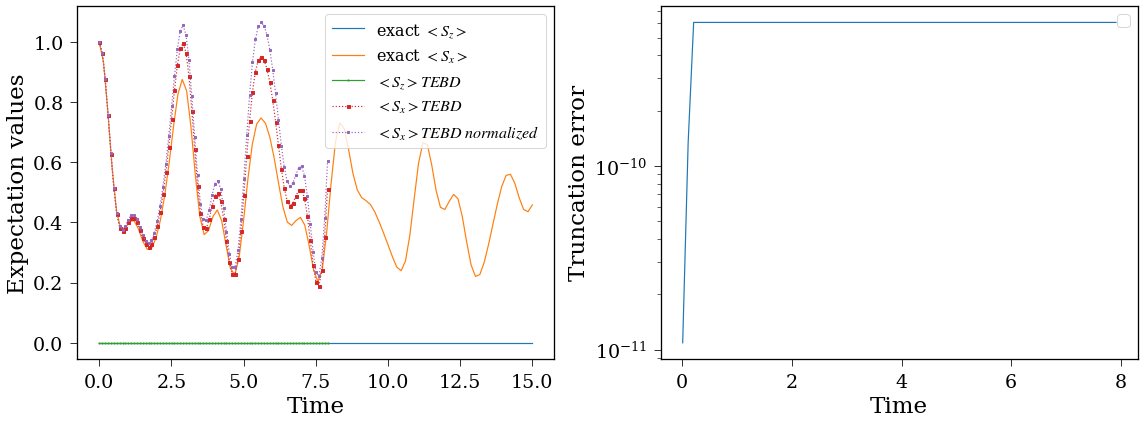

In [25]:
import matplotlib.pyplot as plt
csfont = {'fontname':'Comic Sans MS'}
hfont = {'fontname':'Helvetica'}

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16,6))
ax[0].plot(tlist, np.array(mz_ex), label="exact $<S_z>$")
ax[0].plot(tlist, 1*np.array(mx_ex),label="exact $<S_x>$")


ax[1].plot(ts, disc_err)
ax[1].set_yscale('log')
ax[0].plot(ts, mag_t, marker="s", ms=1, label='$<S_z> TEBD$')
ax[0].plot(ts, 1*np.array(mx_ts),marker="s", ms=3, ls = ":", label='$<S_x> TEBD$')
ax[0].plot(ts, 1*np.array(mx_ts_norms),marker="s", ms=2.5, ls = ":", label='$<S_x> TEBD~normalized$')

ax[0].set_xlabel('Time')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Truncation error')
ax[0].set_ylabel('Expectation values') 
ax[0].legend(fontsize=16)
plt.legend(fontsize=16)  
plt.tight_layout()
plt.show() 

In [26]:
mx_ts_norms[-1]

(0.6052427510803247+2.967403556684658e-16j)

In [27]:
Hb = BondHamiltonian(L, Jxs, Jys, Jzs, hxs, hzs, mus)

In [28]:
sx = np.array([[0,1],[1,0]])
mat = np.reshape(np.arange(0,6), (2,3))

In [29]:
sxx = np.kron(sx, mat)
from scipy.linalg import expm, eigh
from numpy.linalg import svd
#esx = expm(sxx)
#esx

In [30]:
x,y,z = svd(sxx)
np.min([np.sum(y>2 ), 3]), y, np.sum(y>0 )

(2, array([7.34846923, 7.34846923, 1.        , 1.        ]), 4)

In [31]:
def kraus_op_svd(op, dt=0.01, d=2):
    idn = np.reshape(np.eye(d), (d*d, 1))
    op1 = np.reshape(op, (d*d, 1))
    op1 = op1 @ op1.T
    
    op2 = np.conj(op.T) @ op
    op2 = np.reshape(op2, (d*d, 1))
    op2 = op2 @ idn.T
    
    op3 = op.T @ np.conj(op)
    op3 = np.reshape(op3, (1, d*d))
    op3 = idn @ op3
    
    D_op = op1 -0.*op2 - 0.*op3
    
    
    eop = expm(dt*D_op)
    # print(f"D =\n {eop}, \n---\n {eop.T}")
    u,s,v = svd(eop)
    #s = s/sum(s**2)
    s = s**(1/2)
    S = np.diag(s)#**1/2
    #S = S/np.sum(S**2)
    B = u.dot(S)
    B_dag = S.dot(v)
    
    eop1 = B @ B.T
    assert eop1.all() == eop.all()
    B = np.reshape(B, (2,2,4))
    return B

In [32]:
B = kraus_op_svd(Hb.sx)

In [33]:
B

array([[[ 0.        ,  0.        ,  0.        ,  1.        ],
        [-0.71421332, -0.70710678,  0.        ,  0.        ]],

       [[-0.71421332,  0.70710678,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  1.        ,  0.        ]]])

In [34]:
B.shape

(2, 2, 4)

In [35]:
np.sum([0.5, 0.7, 0.2, 1.5], dtype=np.int64)

1

In [36]:
from tensor_networks_simulations.mps.models import TFIMPO, TFIModel, HBond

In [37]:
H = TFIMPO(L, Jxs, Jys, Jzs, hxs, hzs, mus)
Hb = HBond(L, Jxs, Jys, Jzs, hxs, hzs, mus)

In [38]:
Hs = [Hb.h_bond(i) for i in range(L-1)]

In [39]:
ws = H.get_Ws()
w1 = np.reshape(np.transpose(ws[1], (0,2,1,3)), (16,16))
w2 = np.reshape(np.transpose(ws[2], (0,2,1,3)), (16,16))
w1 @ (w2)

array([[ 1. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  1. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  1. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  1. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ],
       [ 1. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  1. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. , -1. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. , -1. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ],
       [ 1. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0

In [40]:
Hs[1]

array([[0.-0.j , 0.-0.4j, 0.-0.4j, 0.+0.j , 0.+0.4j, 0.-0.j , 0.-0.j ,
        0.+0.j , 0.+0.4j, 0.-0.j , 0.-0.j , 0.+0.j , 0.-0.j , 0.-0.j ,
        0.-0.j , 0.-0.j ],
       [0.-0.4j, 0.+2.j , 0.+0.j , 0.-0.4j, 0.-0.j , 0.+0.4j, 0.+0.j ,
        0.-0.j , 0.-0.j , 0.+0.4j, 0.+0.j , 0.-0.j , 0.-0.j , 0.-0.j ,
        0.-0.j , 0.-0.j ],
       [0.-0.4j, 0.+0.j , 0.+2.j , 0.-0.4j, 0.-0.j , 0.+0.j , 0.+0.4j,
        0.-0.j , 0.-0.j , 0.+0.j , 0.+0.4j, 0.-0.j , 0.-0.j , 0.-0.j ,
        0.-0.j , 0.-0.j ],
       [0.+0.j , 0.-0.4j, 0.-0.4j, 0.-0.j , 0.+0.j , 0.-0.j , 0.-0.j ,
        0.+0.4j, 0.+0.j , 0.-0.j , 0.-0.j , 0.+0.4j, 0.-0.j , 0.-0.j ,
        0.-0.j , 0.-0.j ],
       [0.+0.4j, 0.-0.j , 0.-0.j , 0.+0.j , 0.-2.j , 0.-0.4j, 0.-0.4j,
        0.-0.j , 0.-0.j , 0.-0.j , 0.-0.j , 0.-0.j , 0.+0.4j, 0.-0.j ,
        0.-0.j , 0.+0.j ],
       [0.-0.j , 0.+0.4j, 0.+0.j , 0.-0.j , 0.-0.4j, 0.-0.j , 0.-0.j ,
        0.-0.4j, 0.-0.j , 0.-0.j , 0.-0.j , 0.-0.j , 0.-0.j , 0.+0.4j,
        0.+0.

In [41]:
np.reshape((h_loc), (16,16))

NameError: name 'h_loc' is not defined

In [ ]:
H = TFIModel(4, 1.0, 0.8)

In [ ]:
H.H_bonds[1].shape

In [ ]:
H.H_mpo[0].shape

In [ ]:
for i in range(L):